## Data generation & cleaning

In [1]:
!pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 2.3 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/2.0 MB 2.3 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.7 MB/s  0:00:01


In [2]:
# ============================================
# Sales Forecasting Dataset Generator
# ============================================

import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import timedelta
import os

fake = Faker()

np.random.seed(42)
random.seed(42)

# ============================================
# CONFIG
# ============================================

NUM_ROWS = 3000

START_DATE = "2021-11-01"
END_DATE = "2026-04-30"

# ============================================
# STATIC DATA
# ============================================

segments = ["Consumer", "Corporate", "Home Office"]

regions = {
    "South": ["Karachi", "Hyderabad"],
    "North": ["Lahore", "Rawalpindi"],
    "Central": ["Islamabad"],
    "West": ["Quetta", "Multan"],
    "East": ["Faisalabad", "Sialkot"]
}

categories = {
    "Electronics": [
        ("Phones", "iPhone 13"),
        ("Accessories", "Wireless Earbuds"),
        ("Accessories", "Gaming Mouse"),
    ],
    "Technology": [
        ("Laptops", "Dell Inspiron"),
        ("Monitors", "Samsung Monitor"),
        ("Tablets", "iPad Air"),
    ],
    "Furniture": [
        ("Chairs", "Office Chair"),
        ("Tables", "Office Desk"),
        ("Storage", "Filing Cabinet"),
    ],
    "Office Supplies": [
        ("Paper", "A4 Printing Paper"),
        ("Binders", "Document Binder Set"),
        ("Pens", "Premium Pen Pack"),
    ]
}

payment_methods = [
    "Credit Card",
    "Debit Card",
    "Bank Transfer",
    "Cash"
]

# ============================================
# DATE GENERATION
# ============================================

date_range = pd.date_range(
    start=START_DATE,
    end=END_DATE,
    freq="D"
)

# ============================================
# GENERATE DATA
# ============================================

rows = []

for i in range(NUM_ROWS):

    order_date = np.random.choice(date_range)

    # Seasonal sales boost
    month = pd.to_datetime(order_date).month

    seasonal_multiplier = 1

    if month in [11, 12]:
        seasonal_multiplier = 1.5

    elif month in [6, 7]:
        seasonal_multiplier = 1.2

    region = random.choice(list(regions.keys()))
    city = random.choice(regions[region])

    category = random.choice(list(categories.keys()))
    sub_category, product_name = random.choice(categories[category])

    quantity = np.random.randint(1, 6)

    base_price = {
        "Electronics": np.random.randint(300, 1500),
        "Technology": np.random.randint(500, 2500),
        "Furniture": np.random.randint(100, 1000),
        "Office Supplies": np.random.randint(10, 200),
    }

    sales = (
        base_price[category]
        * quantity
        * seasonal_multiplier
    )

    discount = round(np.random.uniform(0, 0.20), 2)

    profit_margin = np.random.uniform(0.10, 0.35)

    profit = sales * profit_margin * (1 - discount)

    ship_days = np.random.randint(1, 6)

    ship_date = pd.to_datetime(order_date) + timedelta(days=ship_days)

    row = {
        "Order ID": f"ORD-{1000 + i}",
        "Order Date": order_date,
        "Ship Date": ship_date,
        "Customer ID": f"CUST-{np.random.randint(100,999)}",
        "Customer Name": fake.name(),
        "Segment": random.choice(segments),
        "Country": "Pakistan",
        "City": city,
        "Region": region,
        "Product ID": f"P-{np.random.randint(100,999)}",
        "Category": category,
        "Sub-Category": sub_category,
        "Product Name": product_name,
        "Sales": round(sales, 2),
        "Quantity": quantity,
        "Discount": discount,
        "Profit": round(profit, 2),
        "Payment Method": random.choice(payment_methods)
    }

    rows.append(row)

# ============================================
# CREATE DATAFRAME
# ============================================

df = pd.DataFrame(rows)

# ============================================
# SORT BY DATE
# ============================================

df = df.sort_values("Order Date")

# ============================================
# CREATE DATA FOLDER
# ============================================

os.makedirs("data", exist_ok=True)

# ============================================
# EXPORT CSV
# ============================================

output_path = "data/raw_sales_data.csv"

df.to_csv(output_path, index=False)

# ============================================
# OUTPUT
# ============================================

print("Dataset Generated Successfully")
print(f"Rows: {len(df)}")
print(f"Saved to: {output_path}")

df.head()

Dataset Generated Successfully
Rows: 3000
Saved to: data/raw_sales_data.csv


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Payment Method
1426,ORD-2426,2021-11-01,2021-11-06,CUST-864,Michael Smith,Corporate,Pakistan,Faisalabad,East,P-249,Technology,Tablets,iPad Air,8775.0,5,0.00,1249.98,Credit Card
1860,ORD-2860,2021-11-01,2021-11-06,CUST-599,Cassandra Harrison,Corporate,Pakistan,Islamabad,Central,P-465,Technology,Laptops,Dell Inspiron,3001.5,3,0.06,666.68,Bank Transfer
2703,ORD-3703,2021-11-02,2021-11-04,CUST-502,Michael Edwards,Corporate,Pakistan,Hyderabad,South,P-612,Electronics,Accessories,Wireless Earbuds,1533.0,2,0.07,457.69,Debit Card
192,ORD-1192,2021-11-02,2021-11-06,CUST-685,Karen Lamb,Consumer,Pakistan,Faisalabad,East,P-138,Office Supplies,Pens,Premium Pen Pack,147.0,1,0.10,17.31,Cash
2649,ORD-3649,2021-11-03,2021-11-08,CUST-268,John Padilla,Corporate,Pakistan,Karachi,South,P-875,Furniture,Tables,Office Desk,526.5,3,0.05,151.35,Bank Transfer


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
output_path = r"C:\Users\ayesh\Downloads\commute-time-analytics\data\raw_sales_data.csv"

df.to_csv(output_path, index=False)

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ayesh\Downloads\commute-time-analytics\data\raw_sales_data.csv")

df.shape

(3000, 18)

In [8]:
df.head()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Payment Method
0,ORD-2426,2021-11-01,2021-11-06,CUST-864,Michael Smith,Corporate,Pakistan,Faisalabad,East,P-249,Technology,Tablets,iPad Air,8775.0,5,0.00,1249.98,Credit Card
1,ORD-2860,2021-11-01,2021-11-06,CUST-599,Cassandra Harrison,Corporate,Pakistan,Islamabad,Central,P-465,Technology,Laptops,Dell Inspiron,3001.5,3,0.06,666.68,Bank Transfer
2,ORD-3703,2021-11-02,2021-11-04,CUST-502,Michael Edwards,Corporate,Pakistan,Hyderabad,South,P-612,Electronics,Accessories,Wireless Earbuds,1533.0,2,0.07,457.69,Debit Card
3,ORD-1192,2021-11-02,2021-11-06,CUST-685,Karen Lamb,Consumer,Pakistan,Faisalabad,East,P-138,Office Supplies,Pens,Premium Pen Pack,147.0,1,0.10,17.31,Cash
4,ORD-3649,2021-11-03,2021-11-08,CUST-268,John Padilla,Corporate,Pakistan,Karachi,South,P-875,Furniture,Tables,Office Desk,526.5,3,0.05,151.35,Bank Transfer


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        3000 non-null   object 
 1   Order Date      3000 non-null   object 
 2   Ship Date       3000 non-null   object 
 3   Customer ID     3000 non-null   object 
 4   Customer Name   3000 non-null   object 
 5   Segment         3000 non-null   object 
 6   Country         3000 non-null   object 
 7   City            3000 non-null   object 
 8   Region          3000 non-null   object 
 9   Product ID      3000 non-null   object 
 10  Category        3000 non-null   object 
 11  Sub-Category    3000 non-null   object 
 12  Product Name    3000 non-null   object 
 13  Sales           3000 non-null   float64
 14  Quantity        3000 non-null   int64  
 15  Discount        3000 non-null   float64
 16  Profit          3000 non-null   float64
 17  Payment Method  3000 non-null   o

In [10]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Payment Method    0
dtype: int64

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [13]:
monthly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2021-11-30,219168.0
1,2021-12-31,208171.5
2,2022-01-31,91506.0
3,2022-02-28,89053.0
4,2022-03-31,196785.0


## Exploratory data analysis (EDA)

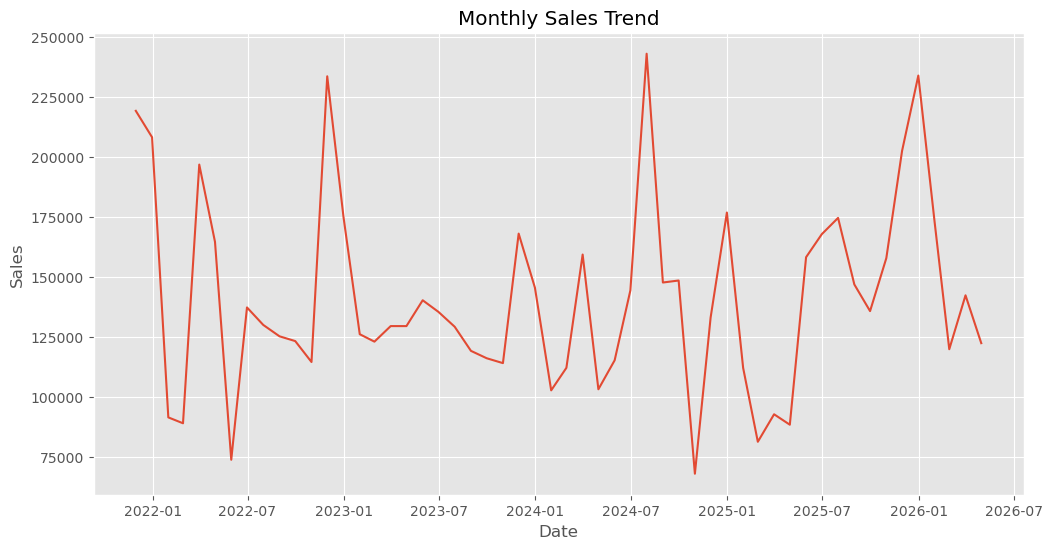

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(data=monthly_sales, x="Order Date", y="Sales")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

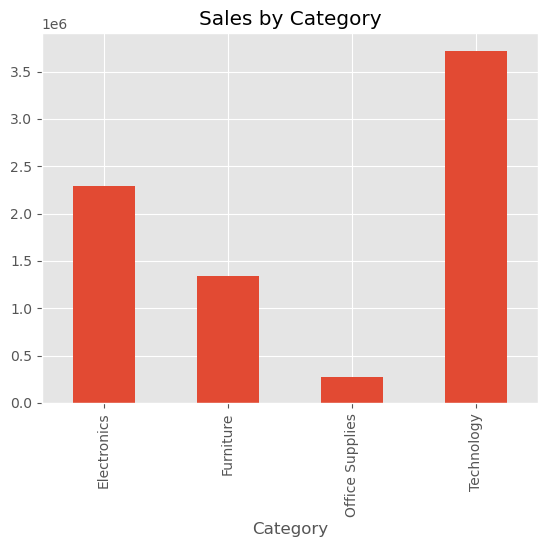

In [15]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Category")
plt.show()

## Forecasting models

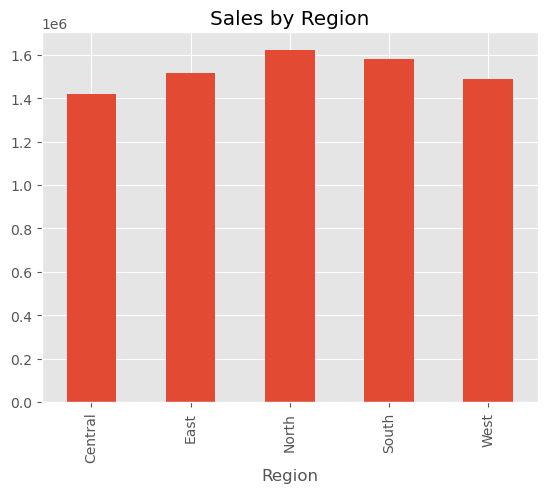

In [16]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Region")
plt.show()

In [17]:
!pip install statsmodels prophet scikit-learn

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 3.0 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.1 MB 3.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.1 MB 1.8 MB/s eta 0:00:06
   ------- -------------------------------- 2.4/12.1 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/12.1 MB 2.5 MB/s eta 0:00:04
   ----------- ---------------------------- 3.4/12.1 MB 2.3 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 2.3 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.3 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.2 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.2 MB/s eta 0:00:04
   -----------------

In [19]:
ts = monthly_sales.copy()
ts = ts.set_index("Order Date")
ts = ts.asfreq("ME")  # ensures proper time series frequency

ts.head()

,Sales
Order Date,
2021-11-30,219168.0
2021-12-31,208171.5
2022-01-31,91506.0
2022-02-28,89053.0
2022-03-31,196785.0


### MODEL 1 — ARIMA

In [20]:
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

In [21]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["Sales"], order=(2,1,2))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(test))

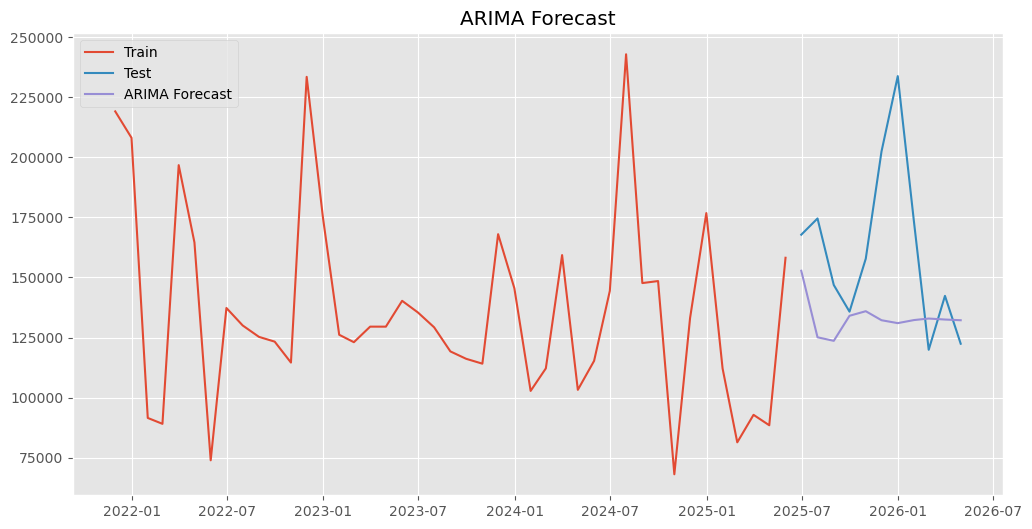

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test")
plt.plot(test.index, arima_pred, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

### MODEL 2 — PROPHET

In [23]:
from prophet import Prophet

prophet_df = monthly_sales.rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

In [24]:
model = Prophet()
model.fit(prophet_df.iloc[:train_size])

15:57:46 - cmdstanpy - INFO - Chain [1] start processing
15:57:47 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = model.make_future_dataframe(periods=len(test), freq='ME')
forecast = model.predict(future)

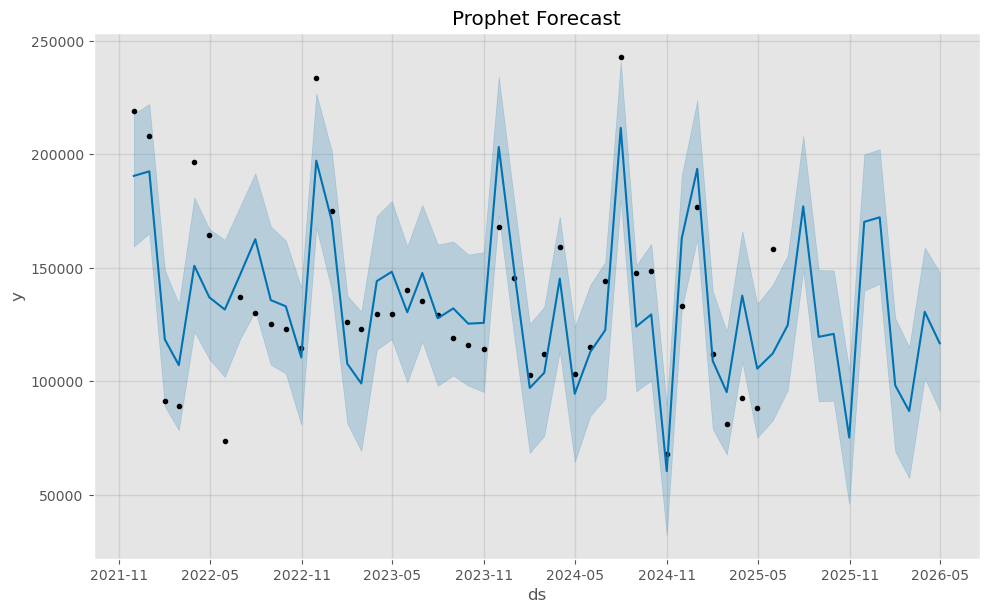

In [27]:
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

### MODEL 3 — RANDOM FOREST

In [28]:
ts_ml = monthly_sales.copy()

ts_ml["Month"] = ts_ml["Order Date"].dt.month
ts_ml["Year"] = ts_ml["Order Date"].dt.year

In [29]:
from sklearn.ensemble import RandomForestRegressor

X = ts_ml[["Month", "Year"]]
y = ts_ml["Sales"]

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(actual, pred, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae}

results = []

results.append(evaluate(test["Sales"], arima_pred, "ARIMA"))
results.append(evaluate(test["Sales"], rf_pred, "Random Forest"))

results

[{'Model': 'ARIMA',
  'RMSE': np.float64(43938.98259895987),
  'MAE': 32533.238675214085},
 {'Model': 'Random Forest',
  'RMSE': np.float64(42290.99640284948),
  'MAE': 35761.278000000006}]

## Generate report

In [33]:
import os

os.makedirs("output", exist_ok=True)

output_file = "output/sales_forecast_report.xlsx"

In [34]:
import os
os.getcwd()

'C:\\Users\\ayesh'

In [35]:
arima_results = test.copy()
arima_results["ARIMA_Pred"] = arima_pred.values

In [36]:
rf_results = test.copy()
rf_results["RF_Pred"] = rf_pred

In [37]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

performance = [
    {"Model": "ARIMA", **metrics(test["Sales"], arima_pred)},
    {"Model": "Random Forest", **metrics(test["Sales"], rf_pred)}
]

In [38]:
import pandas as pd

performance_df = pd.DataFrame(performance)

In [39]:
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    df.to_excel(writer, sheet_name="Raw_Data", index=False)

    monthly_sales.to_excel(writer, sheet_name="Monthly_Sales", index=False)

    arima_results.to_excel(writer, sheet_name="ARIMA_Results", index=False)

    rf_results.to_excel(writer, sheet_name="RF_Results", index=False)

    performance_df.to_excel(writer, sheet_name="Model_Performance", index=False)

print("Excel Report Generated Successfully:", output_file)

Excel Report Generated Successfully: output/sales_forecast_report.xlsx


In [40]:
import pandas as pd

pd.read_excel(output_file).head()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Payment Method
0,ORD-2426,2021-11-01,2021-11-06,CUST-864,Michael Smith,Corporate,Pakistan,Faisalabad,East,P-249,Technology,Tablets,iPad Air,8775.0,5,0.00,1249.98,Credit Card
1,ORD-2860,2021-11-01,2021-11-06,CUST-599,Cassandra Harrison,Corporate,Pakistan,Islamabad,Central,P-465,Technology,Laptops,Dell Inspiron,3001.5,3,0.06,666.68,Bank Transfer
2,ORD-3703,2021-11-02,2021-11-04,CUST-502,Michael Edwards,Corporate,Pakistan,Hyderabad,South,P-612,Electronics,Accessories,Wireless Earbuds,1533.0,2,0.07,457.69,Debit Card
3,ORD-1192,2021-11-02,2021-11-06,CUST-685,Karen Lamb,Consumer,Pakistan,Faisalabad,East,P-138,Office Supplies,Pens,Premium Pen Pack,147.0,1,0.10,17.31,Cash
4,ORD-3649,2021-11-03,2021-11-08,CUST-268,John Padilla,Corporate,Pakistan,Karachi,South,P-875,Furniture,Tables,Office Desk,526.5,3,0.05,151.35,Bank Transfer


In [41]:
import os

os.path.abspath("output/sales_forecast_report.xlsx")

'C:\\Users\\ayesh\\output\\sales_forecast_report.xlsx'